## Data Set : NationalNames.csv 
download : https://drive.google.com/file/d/0B9fcvsgEhJNsN0FUaGZudFYyTVU/view

-  Id: 행 구분자 

-  Name: 유아 이름

-  Year: 출생연도

-  Gender: 성별

-  Count: 해당 (이름, 연도, 성별)의 출생횟수

### 문제 1) NationalNames.csv 파일을 읽어오고, 컬럼을 'id', 'name', 'year', 'sex', 'births' 로 바꾸기 
- dataframe으로 읽어올 것
- 'names' 변수에 저장할 것

In [ ]:
#1) import 하기 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt   # 시각화 라이브러리 
import seaborn as sns
import plotly as px
import folium 

In [5]:
#2) 파일 읽어오기 
names = pd.read_csv('./data/NationalNames.csv')

In [6]:
#3) 컬럼명 변경 
names.columns = ['id','name','year','sex','births']

In [7]:
names

,id,name,year,sex,births
0,1,Mary,1880,F,7065
1,2,Anna,1880,F,2604
2,3,Emma,1880,F,2003
3,4,Elizabeth,1880,F,1939
4,5,Minnie,1880,F,1746
...,...,...,...,...,...
1825428,1825429,Zykeem,2014,M,5
1825429,1825430,Zymeer,2014,M,5
1825430,1825431,Zymiere,2014,M,5
1825431,1825432,Zyran,2014,M,5


### 문제 2) 2012년 이후에 태어난  'Emma' 이름을 가진 남자 아이에 대한 총 출생횟수 구하기 

In [30]:
#정답 [불리언인덱싱 방법 많이 쓰임]

a = names.loc[(names['year'] >= 2012) & (names['name'] == 'Emma') & (names['sex'] == 'M'), :]

total_births_Emma = a['births'].sum()

print('>> 2012년 이후 남자 Emma 이름의 총 출생횟수 : {}명'.format(total_births_Emma))

>> 2012년 이후 남자 Emma 이름의 총 출생횟수 : 50명


In [9]:
result = names[
    (names['year']>=2012)&
    (names['name'] == 'Emma') &
    (names['sex'] == 'M')
]['births'].sum()

result

np.int64(50)

### 문제 3) 각 연도별 남아와 여아의 총 출생횟수를 산출하고, 라인 플롯으로 나타내기 
- index : 연도
- 출력 컬럼 : 여아, 남아
- value :각 연도별 여아 총 출생횟수, 남아 총 출생횟수
- 라인플롯의 제목 : 'The graph showing changes for births per year' 

In [36]:
# 정답 
total_birth = names.pivot_table('births', index='year', columns='sex', aggfunc='sum')
total_birth.head()

sex,F,M
year,,
1880,90993,110491
1881,91954,100745
1882,107850,113688
1883,112321,104629
1884,129022,114445


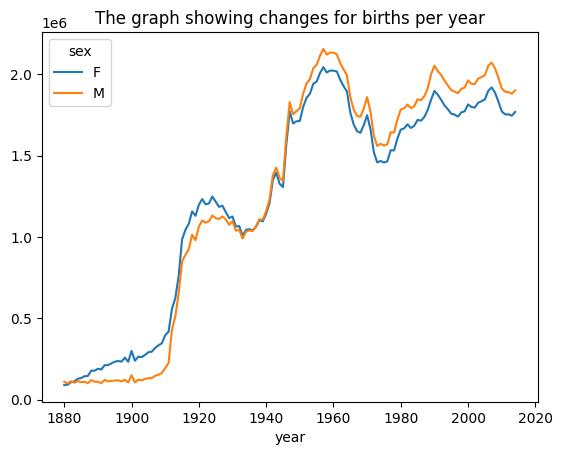

In [35]:
ax = total_birth.plot(title='The graph showing changes for births per year')

In [10]:

import matplotlib.pyplot as plt

# 연도별, 성별 총 출생횟수
births_by_year = names.groupby(['year', 'sex'])['births'].sum().unstack()

# 컬럼명 변경
births_by_year.columns = ['Female', 'Male']

# 결과 확인
births_by_year.head()

,Female,Male
year,,
1880,90993,110491
1881,91954,100745
1882,107850,113688
1883,112321,104629
1884,129022,114445


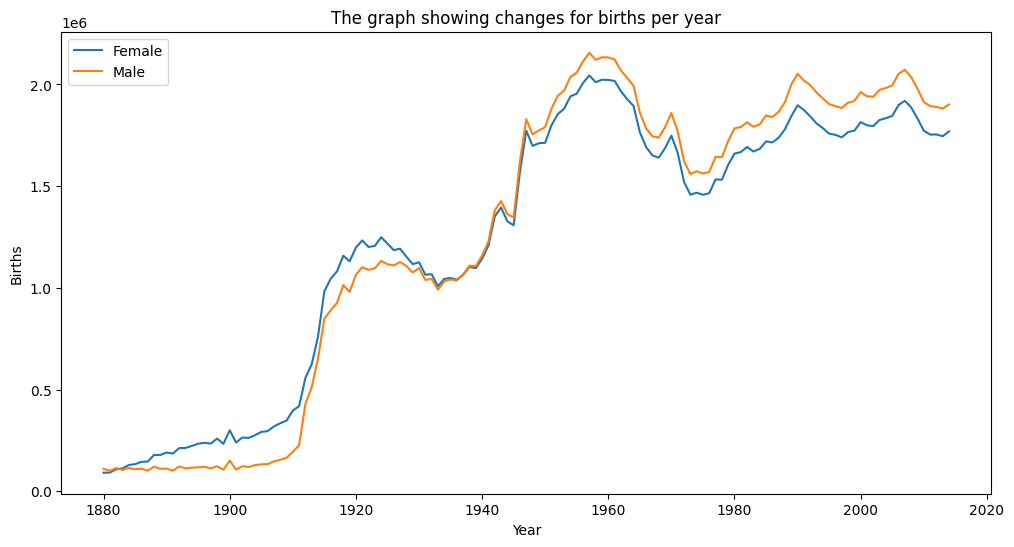

In [11]:
births_by_year.plot(figsize=(12, 6))

plt.title('The graph showing changes for births per year')
plt.xlabel('Year')
plt.ylabel('Births')
plt.show()

### 문제 4) 각 연도, 성별 그룹 내에서 각 이름의 출생횟수가 각 그룹에서 차지하는 비중(%)을 나타내는 열 추가하기  
 - 추가 열이름 : 'pct'로 생성 
 - 'pct'열에 각 연도, 성별 그룹내의 각 이름에 대한 출생횟수 비중을 계산하여 추가

In [14]:
names['pct'] = (
    names['births'] /
    names.groupby(['year', 'sex'])['births'].transform('sum')
) * 100

names.head()

,id,name,year,sex,births,pct
0,1,Mary,1880,F,7065,7.764334
1,2,Anna,1880,F,2604,2.861759
2,3,Emma,1880,F,2003,2.201268
3,4,Elizabeth,1880,F,1939,2.130933
4,5,Minnie,1880,F,1746,1.918829


## 5. 각 연도별, 성별에 따른 출생 빈도수가 가장 높은 이름 100개 추출하기

In [15]:
top100 = (
    names
    .sort_values(['year', 'sex', 'births'], ascending=[True, True, False])
    .groupby(['year', 'sex'])
    .head(100)
)

top100.head()

,id,name,year,sex,births,pct
0,1,Mary,1880,F,7065,7.764334
1,2,Anna,1880,F,2604,2.861759
2,3,Emma,1880,F,2003,2.201268
3,4,Elizabeth,1880,F,1939,2.130933
4,5,Minnie,1880,F,1746,1.918829


## 6. 남자아이 / 여자아이 이름에 대한 시대별 추이 구하기 
 -  전체연도에서 성별구분없이 가장 많이 출생한 이름 top10을 구해서 
    top10에 해당하는 이름에 대한 출생횟수 변화추이를 각각 이름별로 
    subplot 10행 1열의 라인플롯으로 나타낸다
      
 - 그래프를 기반으로 결과 도출 (2000년을 기준으로 전에는 어떤 이름들이 
   유행했고, 이후에는 어떤 이름들이 유행했는지 확인)
   
 - 하기 subplot과 같은 방식으로 그래프 생성하기 

In [24]:
top10 = (
    names.groupby('name')['births']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10

top10_names = top10.index.tolist()

top10_names

['James',
 'John',
 'Robert',
 'Michael',
 'Mary',
 'William',
 'David',
 'Joseph',
 'Richard',
 'Charles']

In [26]:
#) 6_2

top10_data = names[
    names['name'].isin(top10_names)
]

top10_data.head()


top10_year = (
    top10_data
    .groupby(['year', 'name'])['births']
    .sum()
    .reset_index()
)

top10_year.head()


,year,name,births
0,1880,Charles,5359
1,1880,David,869
2,1880,James,5949
3,1880,John,9701
4,1880,Joseph,2642


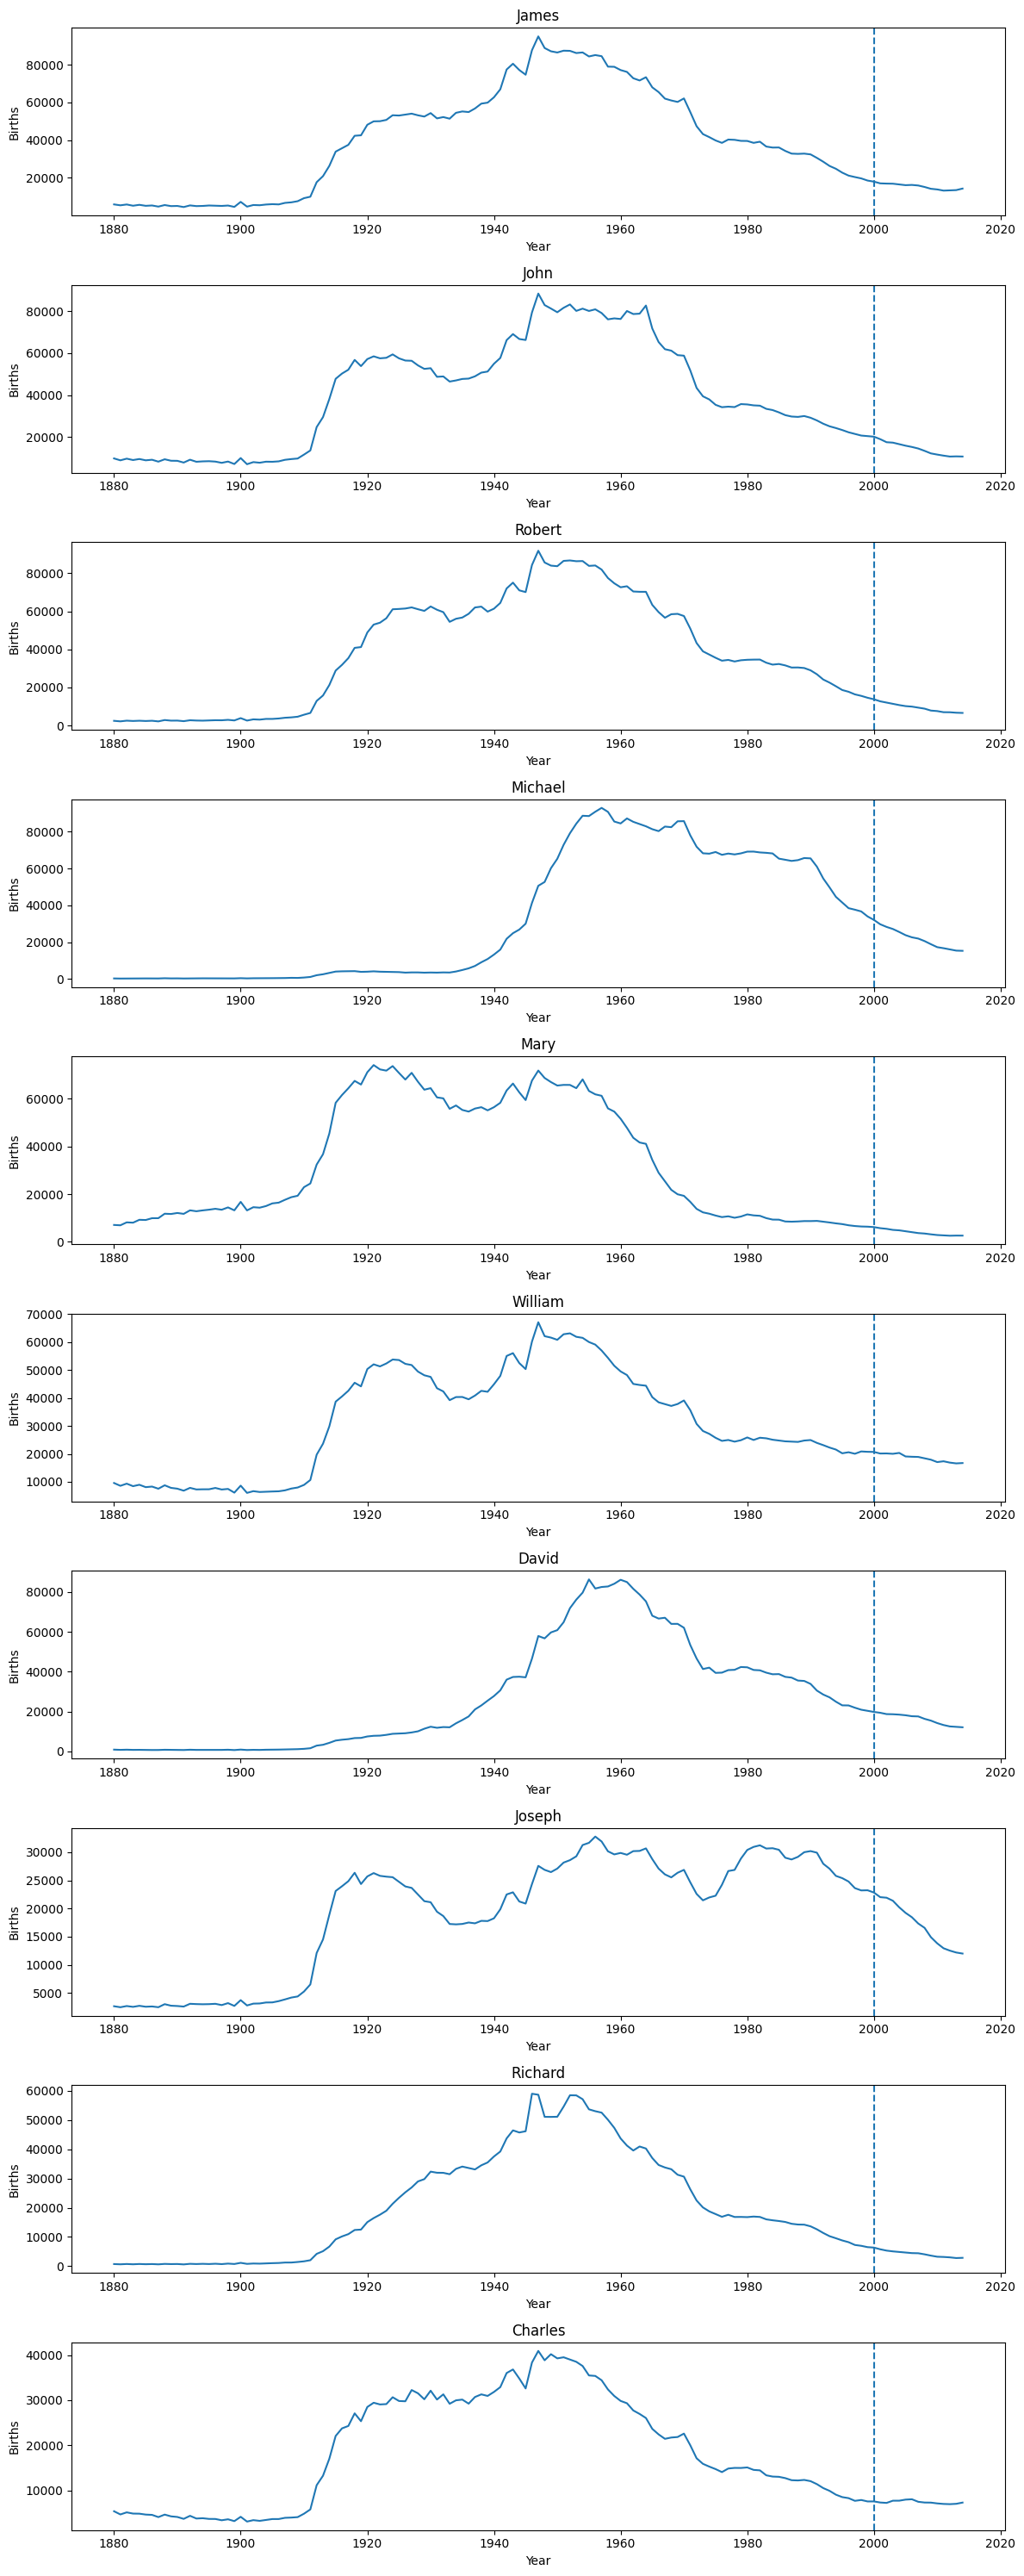

In [27]:
fig, axes = plt.subplots(
    10,
    1,
    figsize=(12, 30)
)

for i, name in enumerate(top10_names):
    
    data = top10_year[
        top10_year['name'] == name
    ]
    
    axes[i].plot(
        data['year'],
        data['births']
    )
    
    axes[i].set_title(name)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Births')
    axes[i].axvline(
        x=2000,
        linestyle='--'
    )

plt.tight_layout()
plt.show()